# DenseNet121 Baseline - Paddy Disease Classification

This notebook trains a DenseNet121 baseline on Kaggle GPU for comparison with the Adaptive DenseNet Layer model.

In [3]:
import os
import csv
import time
import copy
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


In [4]:
SEED = 42
DATA_DIR = Path('/kaggle/input/competitions/paddy-disease-classification')
OUTPUT_DIR = Path('/kaggle/working/densenet121_baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 10
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.2
PATIENCE = 6
NUM_WORKERS = 2

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
def read_train_csv(csv_path):
    rows = []
    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append((row['image_id'], row['label']))
    return rows


def stratified_split(rows, val_ratio=0.2, seed=42):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for image_id, label in rows:
        by_class[label].append((image_id, label))

    train_rows, val_rows = [], []
    for label, items in sorted(by_class.items()):
        rng.shuffle(items)
        val_count = max(1, round(len(items) * val_ratio))
        val_rows.extend(items[:val_count])
        train_rows.extend(items[val_count:])

    rng.shuffle(train_rows)
    rng.shuffle(val_rows)
    return train_rows, val_rows


rows = read_train_csv(DATA_DIR / 'train.csv')
class_names = sorted({label for _, label in rows})
class_to_idx = {name: i for i, name in enumerate(class_names)}
train_rows, val_rows = stratified_split(rows, VAL_RATIO, SEED)

print('classes:', class_names)
print('train:', len(train_rows))
print('val:', len(val_rows))

classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
train: 8325
val: 2082


In [6]:
class PaddyDataset(Dataset):
    def __init__(self, rows, image_root, class_to_idx, transform=None):
        self.rows = rows
        self.image_root = Path(image_root)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def _image_path(self, image_id, label):
        nested = self.image_root / label / image_id
        if nested.exists():
            return nested
        flat = self.image_root / image_id
        if flat.exists():
            return flat
        raise FileNotFoundError(f'Missing image: {nested} or {flat}')

    def __getitem__(self, idx):
        image_id, label = self.rows[idx]
        image = Image.open(self._image_path(image_id, label)).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, self.class_to_idx[label]


imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds = PaddyDataset(train_rows, DATA_DIR / 'train_images', class_to_idx, train_tfms)
val_ds = PaddyDataset(val_rows, DATA_DIR / 'train_images', class_to_idx, val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

In [7]:
weights = models.DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights)
model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')

param_count = sum(p.numel() for p in model.parameters())
size_mb = sum(t.numel() * t.element_size() for t in list(model.parameters()) + list(model.buffers())) / (1024 * 1024)
print('parameters:', param_count)
print('size_mb:', round(size_mb, 2))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 159MB/s] 


parameters: 6964106
size_mb: 26.89


In [8]:
def classification_metrics(y_true, y_pred, num_classes):
    cm = [[0 for _ in range(num_classes)] for _ in range(num_classes)]
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    precisions, recalls, f1s = [], [], []
    for c in range(num_classes):
        tp = cm[c][c]
        fp = sum(cm[r][c] for r in range(num_classes) if r != c)
        fn = sum(cm[c][r] for r in range(num_classes) if r != c)
        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    correct = sum(cm[c][c] for c in range(num_classes))
    total = len(y_true)
    return {
        'accuracy': correct / total,
        'precision': sum(precisions) / num_classes,
        'recall': sum(recalls) / num_classes,
        'f1': sum(f1s) / num_classes,
        'confusion_matrix': cm,
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(images)
            loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
    metrics = classification_metrics(y_true, y_pred, NUM_CLASSES)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

In [9]:
best_f1 = -1.0
bad_epochs = 0
best_path = OUTPUT_DIR / 'best_model.pt'
metrics_path = OUTPUT_DIR / 'metrics.csv'

with open(metrics_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_precision', 'val_recall', 'val_f1'])

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()
    running_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch = labels.size(0)
        running_loss += loss.item() * batch
        correct += (logits.argmax(1) == labels).sum().item()
        seen += batch

    train_loss = running_loss / seen
    train_acc = correct / seen
    val = evaluate(model, val_loader)

    with open(metrics_path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([epoch, train_loss, train_acc, val['loss'], val['accuracy'], val['precision'], val['recall'], val['f1']])

    if val['f1'] > best_f1:
        best_f1 = val['f1']
        bad_epochs = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'metrics': val,
            'class_names': class_names,
            'parameters': param_count,
            'size_mb': size_mb,
        }, best_path)
    else:
        bad_epochs += 1

    elapsed = time.time() - start
    print(
        f"epoch={epoch:03d} train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val['loss']:.4f} val_acc={val['accuracy']:.4f} val_f1={val['f1']:.4f} "
        f"time={elapsed:.1f}s"
    )

    if bad_epochs >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print('best_f1:', best_f1)
print('best checkpoint:', best_path)
print('metrics:', metrics_path)

epoch=001 train_loss=1.0700 train_acc=0.6586 val_loss=0.5447 val_acc=0.8381 val_f1=0.8064 time=115.0s
epoch=002 train_loss=0.3880 train_acc=0.8855 val_loss=0.3243 val_acc=0.8972 val_f1=0.8862 time=55.5s
epoch=003 train_loss=0.2102 train_acc=0.9380 val_loss=0.2419 val_acc=0.9275 val_f1=0.9162 time=56.1s
epoch=004 train_loss=0.1495 train_acc=0.9562 val_loss=0.2008 val_acc=0.9404 val_f1=0.9325 time=55.8s
epoch=005 train_loss=0.1095 train_acc=0.9692 val_loss=0.1813 val_acc=0.9515 val_f1=0.9450 time=56.9s
epoch=006 train_loss=0.0889 train_acc=0.9748 val_loss=0.1621 val_acc=0.9534 val_f1=0.9489 time=55.0s
epoch=007 train_loss=0.0754 train_acc=0.9760 val_loss=0.1444 val_acc=0.9635 val_f1=0.9612 time=51.5s
epoch=008 train_loss=0.0665 train_acc=0.9805 val_loss=0.1589 val_acc=0.9544 val_f1=0.9466 time=50.8s
epoch=009 train_loss=0.0573 train_acc=0.9835 val_loss=0.1491 val_acc=0.9582 val_f1=0.9545 time=51.7s
epoch=010 train_loss=0.0543 train_acc=0.9837 val_loss=0.1804 val_acc=0.9577 val_f1=0.9547 

In [10]:
checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
final_metrics = evaluate(model, val_loader)
final_metrics

{'accuracy': 0.9678194044188281,
 'precision': 0.9734661817104705,
 'recall': 0.9602902127275946,
 'f1': 0.9664481279020695,
 'confusion_matrix': [[92, 0, 0, 1, 0, 0, 0, 1, 0, 2],
  [0, 74, 0, 1, 0, 1, 0, 0, 0, 0],
  [0, 0, 64, 1, 0, 2, 0, 0, 0, 0],
  [0, 0, 0, 347, 0, 0, 0, 0, 0, 1],
  [0, 1, 0, 10, 181, 0, 0, 1, 0, 0],
  [0, 0, 1, 0, 0, 287, 0, 0, 0, 0],
  [0, 0, 0, 6, 6, 0, 109, 0, 1, 2],
  [1, 0, 0, 2, 0, 0, 1, 306, 9, 0],
  [0, 0, 0, 2, 0, 2, 2, 5, 342, 0],
  [0, 0, 0, 2, 0, 0, 0, 2, 1, 213]],
 'loss': 0.1364051950997051}

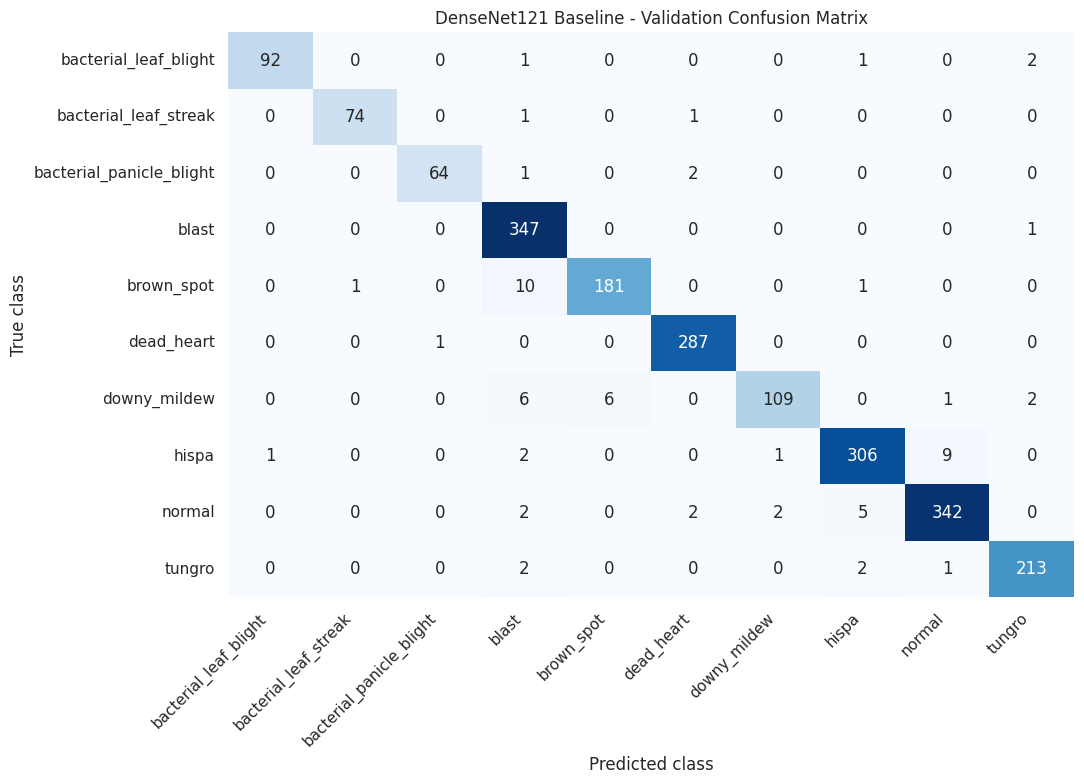

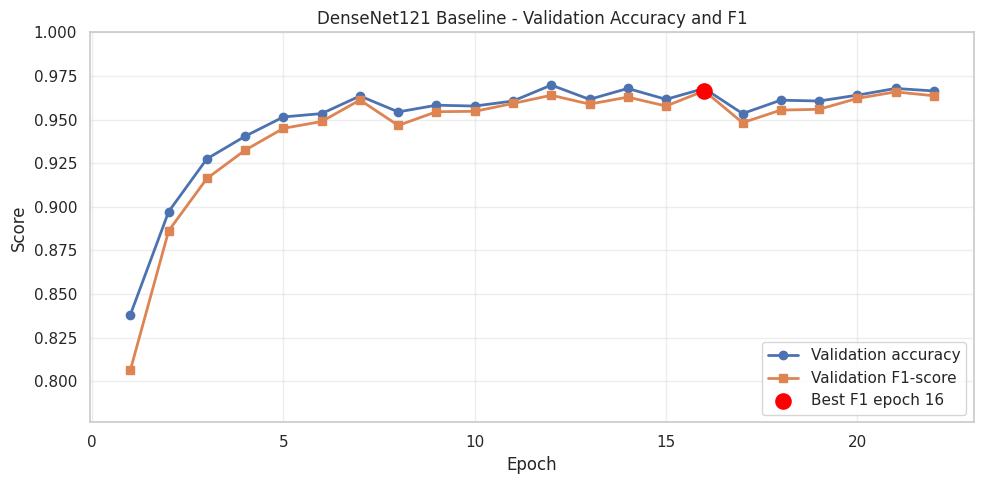

Saved figures:
/kaggle/working/densenet121_baseline/confusion_matrix.png
/kaggle/working/densenet121_baseline/validation_metrics.png


In [11]:
sns.set_theme(style='whitegrid', font_scale=1.0)

# Confusion matrix heatmap
cm = final_metrics['confusion_matrix']
plt.figure(figsize=(11, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
)
plt.title('DenseNet121 Baseline - Validation Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# Validation accuracy and F1 curves
history = pd.read_csv(metrics_path)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['epoch'], history['val_acc'], marker='o', linewidth=2, label='Validation accuracy')
ax.plot(history['epoch'], history['val_f1'], marker='s', linewidth=2, label='Validation F1-score')
best_idx = history['val_f1'].idxmax()
best_epoch = int(history.loc[best_idx, 'epoch'])
best_f1_value = history.loc[best_idx, 'val_f1']
ax.scatter([best_epoch], [best_f1_value], s=120, color='red', zorder=5, label=f'Best F1 epoch {best_epoch}')
ax.set_title('DenseNet121 Baseline - Validation Accuracy and F1')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_ylim(max(0.0, history[['val_acc', 'val_f1']].min().min() - 0.03), 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validation_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved figures:')
print(OUTPUT_DIR / 'confusion_matrix.png')
print(OUTPUT_DIR / 'validation_metrics.png')